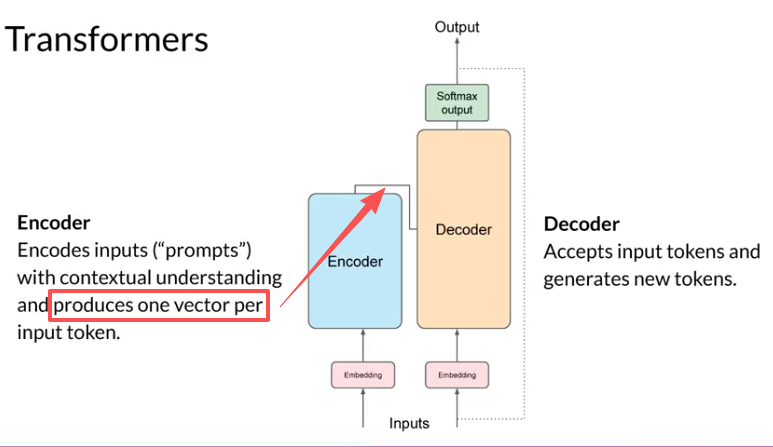
# Transformer 宏观结构梳理

## 1. 整体流程宏观上看

Transformer 主要由两部分组成：

- Encoder（编码器）
- Decoder（解码器）

整体流程可以概括为：

---

## 2. 输入端（Input Processing）

Transformer 的输入处理包含两个关键部分：

### （1）Embedding（嵌入层）

Embedding 由两个组件构成：

- **Token Embedding**
  - 将文本（word / subword）转换为向量表示
- **Positional Embedding**
  - 为每个 token 注入位置信息（因为 Transformer 本身没有顺序结构）

👉 最终结果：
每个输入文本被转换为：
token → 向量表示（包含语义 + 位置信息）


---

### （2）Encoder / Decoder 双输入结构

- Encoder 接收：
  - 输入序列的 embedding

- Decoder 接收：
  - 已生成的目标序列（右移后的 token embedding）
  - Encoder 输出

---

## 3. Encoder（编码器）

Encoder 的作用是：

> 对输入 token 进行上下文建模，生成更丰富的语义表示

### 输入：
Embedding 后的 token 向量
### 输出：
每个 token 对应的上下文表示向量（contextual representation）

👉 这些向量会被传递给 Decoder。

---

## 4. Decoder（解码器）

Decoder 的输入包括两部分：

1. Encoder 输出（上下文信息）
2. 已生成的 token（embedding 后）

### Decoder 的核心作用：

> 结合历史输出 + 输入语义，预测下一个 token

---

## 5. 输出层（Softmax）

Decoder 输出会经过：
Linear → Softmax
得到：
最终选择概率最高的 token 作为输出。
---

## 6. 一句话总结

Transformer 的核心逻辑是：

> 通过 Embedding 将文本向量化 → Encoder 建模上下文 → Decoder （结合已生成 token）输出 → Softmax 得到最终结果

In [15]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

1.7.1+cu101
True
NVIDIA GeForce GTX 1050 Ti


In [16]:
dim_model:int = 128 # 我们预定义的embedding维度
num_heads:int = 4
num_encoder_layers:int = 2 # 堆叠两个Encoder
num_decoder_layers:int = 2 # 堆叠两个Decoder
dim_feedForward:int = 256  # 前馈Net维度
max_len:int = 64
batch_size:int = 8

In [17]:
import math
import torch
import torch.nn as nn
import torch.optim as optim

from torchtyping import TensorType, patch_typeguard # 用于tensor shape级类型提示
from typeguard import typechecked
patch_typeguard()

# 固定随机种子
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    
# 设备选择
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


# 1.Embedding 的实现
## 1.1 word Embedding
重点利用 torch.nn.Embedding 将离散的整数索引（如单词 ID、类别 ID）映射为连续的低维向量（目前忽略其中间实现）

我们人工给定一个词汇表大小为vocab_size，其每个索引映射到一个 预定义的dim_model 维的向量

## 1.2 position Embedding
给输入的每个位置（比如句子里的每个单词）加一个 “位置标签”，让模型知道单词的先后顺序。

用正弦 / 余弦函数生成position，既保证位置越近标签越相似，又能支持超长句子；

In [18]:
from utils_Embedding import TokenEmbedding, PositionalEncoding
import torch
from torch import Tensor

# 测试embedder
myEmbedder = TokenEmbedding(vocab_size=1000, dim_model=512)
test_input = torch.randint(0, 1000, (1, 20))  # 随机生成一个batch_size=1, seq_len=10的输入
output:Tensor = myEmbedder(test_input)
print(output.shape)  # 应该输出 [1, 10, 512]

# 测试 positional encoding
myPositionalEncoder = PositionalEncoding(dim_model=512, max_len=max_len)
output:Tensor = myPositionalEncoder(output)
print(output.shape)  # 应该输出 [1, 10, 512]

torch.Size([1, 20, 512])
torch.Size([1, 20, 512])


In [19]:
class InputEmbedding(nn.Module):
    def __init__(self, vocab_size:int, dim_model:int, max_len:int=512, dropout:float=0.1):
        super(InputEmbedding, self).__init__()
        self.token_embedding = TokenEmbedding(vocab_size, dim_model)
        self.position_encoding = PositionalEncoding(dim_model, max_len, dropout)
        self.dim_model = dim_model
        
    @typechecked
    def forward(self, x:TensorType["batch","seq"]) -> TensorType["batch","seq","dim"]:
        x = self.token_embedding(x) * math.sqrt(self.dim_model) # 通常 embedding 乘 sqrt(d_model) 以保持尺度稳定
        '''
            转换为向量的embedding 维度越大 虽然表示能力强 但不压缩会导致 positional encoding 信息被模型忽略
            例如 scale 为 vector内存储的各维度信息平方根, 尺度上自然会超过 position 信息
            通俗例子:
            embedding 的dim为 512好比 麦克风, 但其scale 尺度为 音量=22
            positional则512个麦克风  音量=1  差异过大
            向量中数值的“大小（尺度）”会直接影响梯度、注意力分布、激活函数行为，从而显著影响学习效果与训练稳定性。
            vector [1, 1, 1, 100] 中决策完全被最后一个人控制
        '''
        x = self.position_encoding(x)
        return x

In [20]:
# 测试 InputEmbedding 层
vocab_size = 1000
dim_model = 128
batch_size = 8
seq_len = 10

sample_input = torch.randint(low=0, high=vocab_size, size=(batch_size, seq_len)).to(device) # seq_len假定这是一个被转为tensor的句子

myEmbedding_layer = InputEmbedding(vocab_size, dim_model, max_len=100).to(device)
out:Tensor = myEmbedding_layer(sample_input)
print("Input shape:", sample_input.shape)
print("Embedding output shape:", out.shape)

Input shape: torch.Size([8, 10])
Embedding output shape: torch.Size([8, 10, 128])


# 2.Decoder 部份
2.1 首先是 Decoder 中的 MultiHeadAttention 层

2.2 完成 FeedForward 基本的NN网络

2.3 组装上述成为 Decoder

In [26]:
# 测试 多头自注意力
from utils_Attention import MultiHeadAttention
x = torch.randn(2, 10, 128).to(device)
mha = MultiHeadAttention(d_model=128, n_heads=4).to(device)

out, attn = mha(x, x, x)
out: Tensor
attn: Tensor
print("MHA output shape:", out.shape)
print("Attention shape:", attn.shape)

MHA output shape: torch.Size([2, 10, 128])
Attention shape: torch.Size([2, 4, 10, 10])


In [27]:
# 拼装 Decoder
from utils_Attention import MultiHeadAttention
from utils_FeedForward import FeedForward

class DecoderLayer(nn.Module):
    def __init__(self, dim_model:int, n_heads:int, dim_ff:int, dropout:float=0.1):
        super(DecoderLayer, self).__init__()
        
        self.self_attn = MultiHeadAttention(dim_model=dim_model, n_heads=n_heads, dropout=dropout)
        self.ff = FeedForward(dim_model=dim_model, dim_ff=dim_ff, dropout=dropout)
        
        self.norm1 = nn.LayerNorm(dim_model)
        self.norm2 = nn.LayerNorm(dim_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        
    @typechecked
    def forward(self, x:TensorType["batch","seq", "dim"], src_mask=None) -> TensorType["batch","seq", "dim"]:
        attn_output, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout1(attn_output))
        
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout2(ff_output))
        
        return x
